# ODE Examples from the Internet

## Lodla-Volterra
From https://scipy-cookbook.readthedocs.io/items/LoktaVolterraTutorial.html

- Predator-Prey equation
- system of coupled non-linear differential equations of the first order
- describe interplay between predator and prey populations in an idealized environment
- predator consumes prey, prey reproduces, predator reproduces but depending on the population of prey


$$\frac{dN_1}{dt} = N_1 (\epsilon_1 - \gamma_1 N_2)$$

$$\frac{dN_2}{dt} = -N_2 (\epsilon_2 - \gamma_2 N_1)$$


### Reasoning behind the Equation
(see https://de.wikipedia.org/wiki/Lotka-Volterra-Gleichungen)

- population of prey and predator are designated as $N_1$ and $N_2$, respectivly
- undisturbed growth per time interval $dt$ are designated as $\lambda_1$ and $\lambda_2$ without sign!
- the frequency of predator-prey encounters per $dt$ is $\alpha N_1 N_2$ with $\alpha \geq 0$ and is considered a constant within a biotop
- a great enough number of encounters $n$ have a mean effect $\beta_i$ on the population $N_i$
    - Note: that the effect of a predator-prey encounter has an immediate effect on the prey population is trivial
    - however, the model also assumes that for the predator population; the effect is positive, no doubt, but should be displaced in time, because for the predator it allows reproduction

- based on these general considerations, the SDE is

$$dN_1 = \lambda_1 N_1 dt + \alpha N_1 N_2 \frac{\beta_1}{n}dt \quad | :dt$$

$$dN_2 = \lambda_2 N_2 dt + \alpha N_1 N_2 \frac{\beta_2}{n}dt \quad | :dt$$

- we now divice by $dt$

$$\frac{dN_1}{dt} = \lambda_1 N_1 + \alpha N_1 N_2 \frac{\beta_1}{n}$$

$$\frac{dN_2}{dt} = \lambda_2 N_2 + \alpha N_1 N_2 \frac{\beta_2}{n}$$

- finnaly, we assume, that $\epsilon_1 = \lambda_1$, $\epsilon_2 = - \lambda_2$, $\gamma_1 = -\frac{\alpha \beta_1}{n}$, $\gamma_2 = \frac{\alpha \beta_1}{n}$, and $dt \rightarrow 0$
    - because the predator depends on the prey population for reproduction, we need to change the sign of $\lambda_2$, so that it declines over time; only predator-prey encounters (second term of the predator equation) can raise the predator population
    - the same logic applies to $\gamma_1$, we have to change its sign, because predator-prey encounters remove prey from the population, therefore $\gamma_1 = - \alpha_1 \beta_1 / n$
    
    
*****

- following code assumes

$$\frac{dN_1}{dt} = aN_1 - b N_1 N_2$$

$$\frac{dN_2}{dt} = -c N_2 + d b N_1 N_2$$

- with
    - $a$ as natural growing rate of prey, when there's no predator
    - $b$ as natural dying rate of prey due to predation
    - $c$ as natural dying rate of predators, when there's no prey
    - $d$ as factor describing how many offspring can predators generate per prey

In [1]:
import numpy as np
import pylab as p
from numba import jit, njit

# Defining parameters
a = 1.0
b = 0.1
c = 1.5
#d = 0.75
d = 1

# Function describing the differential equations
#@njit
def dX_dt(X, t = 0):
    """Return the growth rate for the coupled predator-prey popluations at t."""
    N1 = a*X[0] - b*X[0]*X[1]
    N2 = -c*X[1] + d*b*X[0]*X[1]
    return(np.array([N1, N2]))


# Calculating the equilibrium point
X_f0 = np.array([0., 0.]) # Extinction of both species
X_f1 = np.array([c/(d*b), a/b]) # Eq. point of the two species, non-zero!
all(dX_dt(X_f0) == np.zeros(2)) and all(dX_dt(X_f1) == np.zeros(2)) # all() returns true when all iteralble elements return true

# all() example
#all(np.array([1, 2, 3, 4]) == np.array([1, 2, 3, 4])) -> True

# Stability of the equilibrium points using the Jacobian -> linearization around the eq. points!
def d2X_dt2(X, t = 0):
    """Return Jacobian evaluated in X"""
    jac = np.array([[a - b*X[1], -b*X[0]], 
                   [b*d*X[1], -c + b*d*X[0] ]])
    return(jac)


A_f0 = d2X_dt2(X_f0)
print("Jacobian:\n", A_f0) # -> near eq. point, number of prey increased (1.0), whereas number of predators decreases (-1.5)

A_f1 = d2X_dt2(X_f1)
lambda1, lambda2 = np.linalg.eigvals(A_f1)
print("Eigenvalues of Eq. point: \t", lambda1, lambda2)
# -> complex eigenvalues -> population changes of both species are periodic!
T_f1 = 2*np.pi/abs(lambda1)
print("Period: \t", T_f1)
print("*********\n")




# Integrating the ODE with scipy
from scipy import integrate

t = np.linspace(0, 25, 5000)
X0 = np.array([10, 5]) # Initial conditions, population state at t = 0
X, infodict = integrate.odeint(dX_dt, X0, t, full_output = True)
print("\nIntegrator Message: ", infodict['message'])

Jacobian:
 [[ 1.  -0. ]
 [ 0.  -1.5]]
Eigenvalues of Eq. point: 	 1.224744871391589j -1.224744871391589j
Period: 	 5.130199320647456
*********


Integrator Message:  Integration successful.


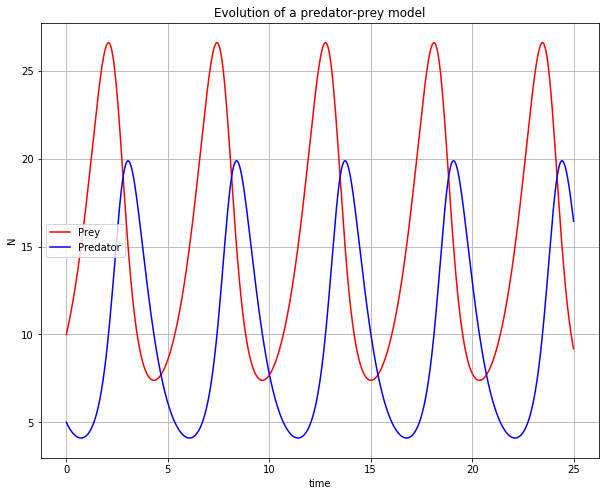

In [2]:
# Plotting the results
prey, predator = X.T
f1 = p.figure(figsize = (10, 8))
p.plot(t, prey, 'r-', label = 'Prey')
p.plot(t, predator, 'b-', label = 'Predator')
p.grid()
p.legend(loc = 'best')
p.xlabel('time')
p.ylabel('N')
p.title('Evolution of a predator-prey model')
p.show()

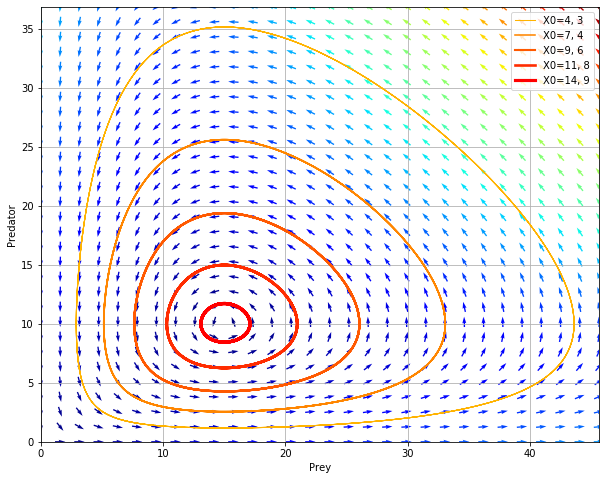

In [3]:
# Plotting direction fields and trajectories
values = np.linspace(0.3, 0.9, 5) # Values of X0 betwen X_f0 and X_f1

vcolors = p.cm.autumn_r(np.linspace(0.3, 1, len(values)))

f2 = p.figure(figsize = (10, 8))
p.xlabel('Prey')
p.ylabel('Predator')


# plotting the trajectories
for v, col in zip(values, vcolors):
    X0 = v * X_f1 # get the starting point
    X = integrate.odeint(dX_dt, X0, t) # we don't need to integrator info here
    p.plot(X[:, 0], X[:, 1], lw = 3.5*v, color = col, label = 'X0=%.f, %.f'%(X0[0], X0[1]))
    
# define grid and compute direction vectors at each grid point
ymax = p.ylim(ymin = 0)[1] # Axis limits from the plot
xmax = p.xlim(xmin = 0)[1]

nb_points = 30

x = np.linspace(0, xmax, nb_points)
y = np.linspace(0, ymax, nb_points)

X1, Y1 = np.meshgrid(x, y) # np.meshgrid() makes a N-dimensional matrix from 1D x and y axes; same thing as for(x): for(y): array[x][y], just much much easier!
DX1, DY1 = dX_dt([X1, Y1]) # compute growth rate at meshgrid points using original ODE

M = (np.hypot(DX1, DY1)) # hypot does element-wise sqrt(x1**2 + x2**2) -> vector normalization!
M[M == 0] = 1.0 # No division by zero!
DX1 /= M # Normalize arrows -> color will code their magnitude later!
DY1 /= M



p.quiver(X1, Y1, DX1, DY1, M, pivot = 'mid', cmap = p.cm.jet)
p.legend()
p.grid()
p.show()

## Brownian Motion
(see https://scipy-cookbook.readthedocs.io/items/BrownianMotion.html)

- Brownian motion is stochastic process of the form

$$X(0) = X_0$$

$$X(t + dt) = X(t) + N(0, \delta^2 dt; t, t + dt)$$

- $N(a, b; t_1, t_2)$ is normally distributed random variable with $\mu = a$ and $\sigma = b$
- $t_1$ and $t_2$ declare the explicity of the statistical independence of $N$ on different time intervals
    - i.e. $[t_1, t_2)$ and $[t_3, t_4)$ are disjointed intervals; this means, that $N(a, b; t_1, t_2)$ are independent
    
- the most complex thing is the reasoning, the calculation is rather simple


In [4]:
from scipy.stats import norm

# Parameters
delta = 0.25
dt = 0.1

# Initial condition
x = 0.0

# Iterations
n = 20


# computing steps of Brownian motion
for k in range(n):
    x = x+ norm.rvs(scale = delta**2 * dt)
    print(x)

-0.0009709969073700571
-0.004654473160844671
-0.0047217443480133585
-0.008964429654568557
-0.0006385446919339923
-0.0061687368444120596
-0.0036290106274016213
-0.005133717166694317
-0.007283827309634667
-0.00588688213464056
-0.0015308070327586442
-0.0017109827438770832
-0.00940090889285474
-0.013948678800256319
-0.010205379587611245
-0.018660555133498215
-0.023264811423739533
-0.027698814632953088
-0.03409821953362845
-0.03269843538445073


In [5]:
# Implementing function to do that

from math import sqrt
from scipy.stats import norm
import numpy as np
from numba import njit
from pylab import plot, show, grid

#@jit
def brownian(x0, n, dt, delta, out = None):
    """
        Generate Brownian motion (i.e. Wiener process): X(t) = X(0) + N(0, delta**2 * t; 0, t)
    """
    
    x0 = np.asarray(x0)
    
    r = norm.rvs(size = x0.shape + (n, ), scale = delta*sqrt(dt))
    
    if out is None:
        out = np.empty(r.shape)
        
    np.cumsum(r, axis = -1, out = out)
    
    out += np.expand_dims(x0, axis = -1)
    
    return(out)




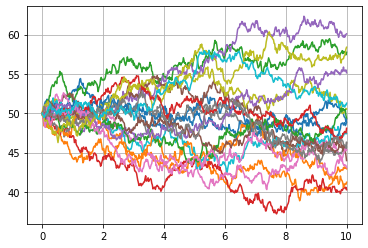

In [6]:
delta = 2

T = 10.0
N = 500
dt = T/N

m = 20 # number of realizations

x = np.empty((m, N+1))

x[:, 0] = 50

brownian(x[:, 0], N, dt, delta, out = x[:, 1:])

t = np.linspace(0.0, N*dt, N+1)

for k in range(m):
    plot(t, x[k])
grid(True)
show()

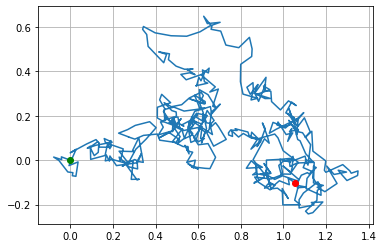

In [7]:
# 2D Brownian Motion

# The Wiener process parameter.
delta = 0.25
# Total time.
T = 10.0
# Number of steps.
N = 500
# Time step size
dt = T/N
# Initial values of x.
x = np.empty((2,N+1))
x[:, 0] = 0.0

brownian(x[:,0], N, dt, delta, out=x[:,1:])

# Plot the 2D trajectory.
plot(x[0],x[1])

# Mark the start and end points.
plot(x[0,0],x[1,0], 'go')
plot(x[0,-1], x[1,-1], 'ro')

# More plot decorations.
grid(True)
show()

## Robust Non-Linear Regression using Scipy

(see https://scipy-cookbook.readthedocs.io/items/robust_regression.html)

- curve fitting by non-linear least squares
    - given pairs $\{(t_i, y_i)i = 1, ..., n \}$, estimate the set of parameters $\mathbf{x}$ defining a non-linear function $\phi(t;\mathbf{x})$ by assuming the model
    
    $$y_i = \phi(t_i; \mathbf{x}) + \epsilon_i$$
    
- with $\epsilon_i$ as measurement error
- with least-squares estimation, we serach for $\mathbf{x}$ as solution of 

$$\frac{1}{2} \sum_{i = 1}^{n} \big( \phi (t_i; \mathbf{x}) - y_i \big)^2 \rightarrow \min_{x}$$


- least-squares is maximum likelihood estimate
    - given that all $\epsilon_i$ are independent and normally distributed random variables
- outliers can contaminate a measurement and interfere with the fitting procedure
    - can lead to solution, which is significantly biased towards the high residuals of the outlier
    
    
- explanation with simple example: consider this optimization problem
 
 
$$\frac{1}{2} \sum_{i = 1}^{n} (a - x)^2 \rightarrow \min_{x}$$

- with the solution in the mean value $a^* = \frac{1}{n} \sum_{i = 1}^{n} x_i$
    - example data are $a = 1$, $n = 4$, $x_1 = 0.9$, $x_2 = 1.05$, $x_3 = 0.95$, $x_4 = 10$ (outlier)
    - $a^* = 3.225$, which isn't true because of the strong influence of the outlier
- well-known and robust estimator is l1-estimator
    - absolute values of residuals are minimized: $$\sum_{i = 1}^{n} | a - x_i | \rightarrow \min_{a}$$
    - the solution is the median of $\{ x_i \}$; in that case the outliers won't affect the solution as strongly
    - $a^* = 1$
    - disadvantage of l1-estimator is, that estimations become hard, when the function is non-differentiable (general problem of nin-linear optimization)
    - i.e. we're better off when we stay with differentiable problems, but try to incorporate robustness in the estimation
- we try to introduce a sublinear function $\rho (z)$ (sublinear = slower growth than linear) and reformulate the least-square(-like) optimization problem: $$\frac{1}{2} \sum_{i = 1}^{n} \rho \big( \phi (t_i; \mathbf{x}) - y_i \big) \rightarrow \min_{x}$$
    - this can be reduced to standard non-linear least-squares by modifying a vector of residuals and Jacobian on each iteration
    - $\rightarrow$ gradient and Hessian approximation match the ones of the objective function
    
- implementation for $\rho$
    1. Linear function, which gives a standard least squares: $\rho(z) = z$
    2. Huber loss: $\rho(z) = \begin{cases} z & z \leq 1 \\ \sqrt{z} - 1 & z > 1 \ \end{cases}$
        - Huber loss (https://en.wikipedia.org/wiki/Huber_loss) is a loss function used in robust regression and less sensitive to outliers than standard squared error loss
        - squared-losses tendency to pronounce the effect of outliers
        - Huber loss is strongly convex and thus has a linear increase of the outlier effect, rather than$\epsilon^2$ in case of squared-loss
        - Huber loss is *relatively mild*
    3. Smooth approximation to absolute value loss, i.e. "soft 1l loss": $\rho (z) = 2 (\sqrt{1 + z} - 1)$
        - also *relatively mild*
    4. Cauchy loss: $\rho (z) = ln(1 + z)$
        - strongly sublinear
    5. Loss by arctan: $\rho (z) = \arctan z$
        - strongly sublinear
    - we assume that threshold between inliers and outliers is 1.0 
        - we introduce $C$ as scaling parameter and evaluate the loss as $\hat{\rho} (r^2) = C^2 \rho \Big( \big( \frac{r}{C} \big) ^2 \Big)$
        - therefore, if $r$ (residuals) are small, $\hat{\rho} (r^2) \approx \rho (r^2) \approx r^2$ for any $\rho(z)$

In [8]:
## Overview plot of loss functions
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rcParams
rcParams['figure.figsize'] = (10, 7)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16

In [9]:
r = np.linspace(0, 5, 100)

linear = r**2

huber = r**2
huber[huber > 1] = 2 * r[huber > 1] - 1

soft_l1 = 2 * (np.sqrt(1 + r**2) - 1)

cauchy = np.log1p(r**2)

arctan = np.arctan(r**2)

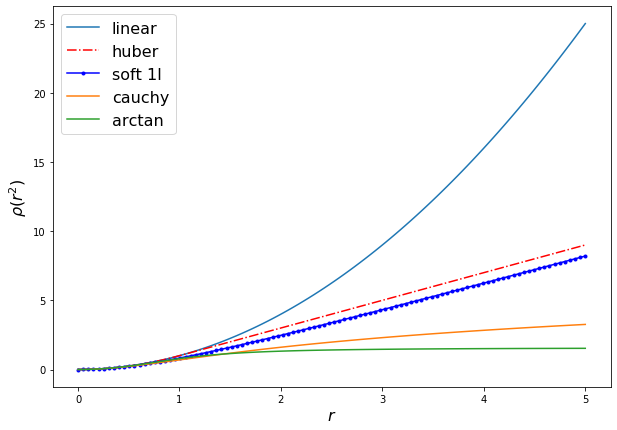

In [10]:
plt.plot(r, linear, label = 'linear')
plt.plot(r, huber, 'r-.', label = 'huber')
plt.plot(r, soft_l1, 'b.-', label = 'soft 1l')
plt.plot(r, cauchy, label = 'cauchy')
plt.plot(r, arctan, label = 'arctan')
plt.xlabel('$r$')
plt.ylabel(r'$\rho(r^2)$')
plt.legend(loc = 'best')

- now as example with the model $f(t; A, \sigma, \omega) = A e^{- \sigma t} \sin(\omega t)$, which is a model for a linearly damped oscillator


In [11]:
def generate_data(t, A, sigma, omega, noise=0, n_outliers=0, random_state=0):
    y = A * np.exp(-sigma * t) * np.sin(omega * t)
    rnd = np.random.RandomState(random_state)
    error = noise * rnd.randn(t.size)
    outliers = rnd.randint(0, t.size, n_outliers)
    error[outliers] *= 35
    return y + error

In [12]:
A = 2
sigma = 0.1
omega = 0.1 * 2 * np.pi
x_true = np.array([A, sigma, omega])

noise = 0.1

t_min = 0
t_max = 30

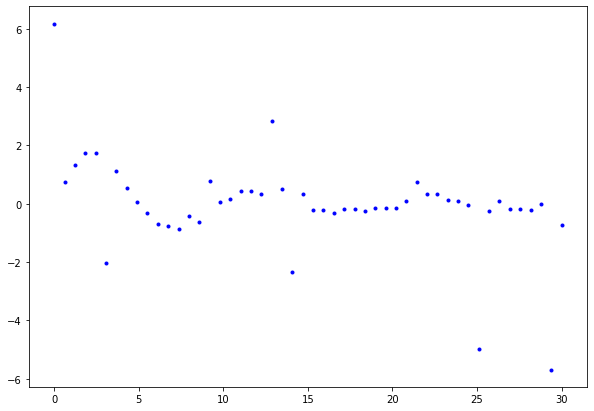

In [13]:
t_train = np.linspace(t_min, t_max, 50)
y_train = generate_data(t_train, A, sigma, omega, noise=noise, n_outliers=10)
plt.plot(t_train, y_train, 'b.')

In [14]:
def fun(x, t, y):
    out = x[0] * np.exp(-x[1] * t) * np.sin(x[2] * t) -y
    
    return(out)

In [15]:
x0 = np.ones(3)

from scipy.optimize import least_squares

res_lsq = least_squares(fun, x0, args = (t_train, y_train))
res_robust = least_squares(fun, x0, loss = 'soft_l1', f_scale = 0.1, args = (t_train, y_train))
res_cauchy = least_squares(fun, x0, loss = 'cauchy', f_scale = 0.1, args = (t_train, y_train))
res_huber = least_squares(fun, x0, loss = 'huber', f_scale = 0.1, args = (t_train, y_train))

t_test = np.linspace(t_min, t_max, 300)
y_test = generate_data(t_test, A, sigma, omega)

y_lsq = generate_data(t_test, *res_lsq.x)
y_robust = generate_data(t_test, *res_robust.x)
y_cauchy = generate_data(t_test, *res_cauchy.x)
y_huber = generate_data(t_test, *res_huber.x)

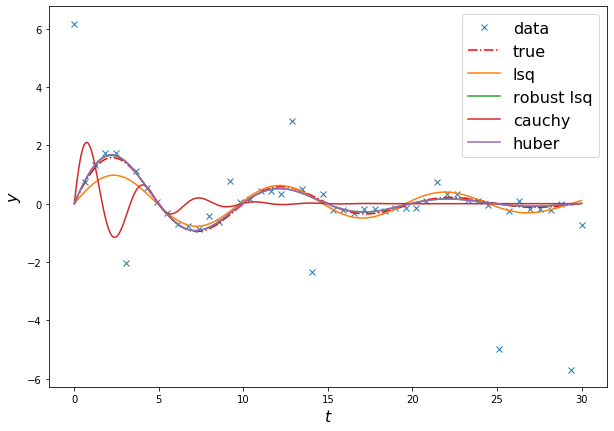

In [16]:
plt.plot(t_train, y_train, 'x', label = 'data')
plt.plot(t_test, y_test, 'r-.', label = 'true')
plt.plot(t_test, y_lsq, label = 'lsq')
plt.plot(t_test, y_robust, label = 'robust lsq')
plt.plot(t_test, y_cauchy, label = 'cauchy')
plt.plot(t_test, y_huber, label = 'huber')
plt.xlabel(r'$t$')
plt.ylabel(r'$y$')
plt.legend()

## Korteweg de Vries Equation
- Korteweg de Vries (KdV) equation is a model of waves on a shallow surface (water) and an example of an analytically solvable non-linear partial differential equation model
- KdV is a non-linaer, dispersive PDE for a function $\phi$ of two real variables space $x$ and time $t$

$$\partial_t \phi + \partial^{3}_x \phi - 6 \phi \partial_x \phi = 0$$

- we'll solve this by the method of lines (http://www.scholarpedia.org/article/Method_of_lines) using the pseudo-spectral method
    - derivatives are computed in frequency domain by applying FFT to the data, then mulpliplying the values and converting back to spatial domain with iFFT
    - implemented by diff() in scipy.fftpack()

In [17]:
import numpy as np
from scipy.integrate import odeint
from scipy.fftpack import diff as psdiff
import matplotlib.pyplot as plt


def kdv_exact(x, c):
    """Profile of the exact solution to the KdV for a single soliton on the real line."""
    u = 0.5*c*np.cosh(0.5*np.sqrt(c)*x)**(-2)
    return u

def kdv(u, t, L):
    """Differential equations for the KdV equation, discretized in x."""
    # Compute the x derivatives using the pseudo-spectral method.
    ux = psdiff(u, period=L)
    uxxx = psdiff(u, period=L, order=3)

    # Compute du/dt.    
    dudt = -6*u*ux - uxxx

    return dudt

def kdv_solution(u0, t, L):
    """Use odeint to solve the KdV equation on a periodic domain.
    
    `u0` is initial condition, `t` is the array of time values at which
    the solution is to be computed, and `L` is the length of the periodic
    domain."""

    sol = odeint(kdv, u0, t, args=(L,), mxstep=5000)
    return sol

In [31]:
L = 50.0
N = 64
dx = L / (N - 1.0)
x = np.linspace(0, (1-1.0/N)*L, N)

    # Set the initial conditions.
    # Not exact for two solitons on a periodic domain, but close enough...
u0 = kdv_exact(x-0.1*L, 1) + kdv_exact(x-0.2*L, 0.4)

    # Set the time sample grid.
T = 200
t = np.linspace(0, T, 501)

print("Computing the solution.")
sol = kdv_solution(u0, t, L)


Computing the solution.


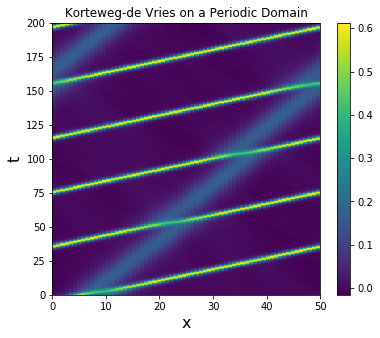

In [32]:
plt.figure(figsize=(6,5))
plt.imshow(sol[::-1, :], extent=[0,L,0,T])
plt.colorbar()
plt.xlabel('x')
plt.ylabel('t')
plt.axis('auto')
plt.title('Korteweg-de Vries on a Periodic Domain')
plt.show()

## ODE Solving using Scipy.integrate.solve_ivp()

- scipy.integrate.solve_ivp() solve an initial value problem for a system of ODEs (https://scipy.github.io/devdocs/generated/scipy.integrate.solve_ivp.html)
- given (set) of functions is numerically integrated starting from given initial values

$$\frac{dy}{dt} = f(t, y)$$

$$y(t_0) = y_0$$

- parameters: solve_ivp(fun, t_span, y0, method = 'RK45', t_eval = None, dense_output = False, events = None, vectorizd = False, args = None, **options**)
    - fun: callable function
        - right-hand side of the system with calling signature f(t, y)
        - t: scalar
        - y: ndarray, can have shape (n, ) or (n, k), when k initial values are given (see first example below); choice set by vectotized option (below)
    - t_span: 2-tuple of floats
        - integration interval, solver starts with $t = 0$ 
    - y0: array-like, $(n, )$
        - initial state vector, can also take complex numbers (even if initial state is only real)
    - method: string or OdeSolver, default: 'RK45'
        - RK45: Explicit Runge-Kutta 
        - ... (see https://scipy.github.io/devdocs/generated/scipy.integrate.solve_ivp.html)
    - t_eval: array-like, optional
        - times at which to store the solution / steps
        - must be explicit times in the range of t_span; if none, solver selects points
    - dense_output: bool, optional
        - compute continuous solution
    - events: callable or list of callables, optional
        - events occur at zeros of a continous function of time and state
        - callables must have signature event(t, y) and return float
        - solver finds value at which event(t, y(t)) = 0 using root-finding
    -  vectorized: bool, optional
        - is fun() implemented in vectorized form, default = False
    - args: tuple, optional
        - additional arguments to pass t fun
        - passed to all user-defined functions
        - e.g., if fun has signature fun(t, y, a, b, c), then any event function and jac() must have the same signature and args must be a tuple of length 3!
    - options: additional options passed to the solver (see https://scipy.github.io/devdocs/generated/scipy.integrate.solve_ivp.html)
        - first_step: float, initial step size
        - max_step: float, maximum allowed step size
        - rtol, atol: float or array-like, relative and absolute tolerances
        - jac: array-like or sparse matrix or callable: Jacobian of right-hand side of the system with respect to y; required by Radau, BDF, and LSODA solver methods
            - Jacobian has shape $(n, n)$, elements are $\frac{df_i}{dy_i}$
            - $J_f(a) := \Big( \frac{\partial f_i}{\partial x_j} (a) \Big)_{i = 1, ..., m; j = 1, ..., n}$
        - lband, uband: int or None, bandwidth of Jacobian for LSODA
        - min_step: float, minimum allowed step size for LSODA, default = 0
        
- returned:
    - t: ndarray $(n)$, time points
    - y: ndarray $(n, k)$, solution(s) at t
    - sol: OdeSolution or None, solution as OdeSolution instance
    - t_events: list of ndarray, each event type as seperate list
    - y_events: y value for each t_event
    - nfev: int, number of evaluations of right-hand side
    - njev: int, number of evaluations of the Jacobian
    - nlu: int, number of LU decompositions
    - status: int, reasons for integration termination
        - -1: integration step failed
        - 0: successfully reached end of tspan
        - 1: termination event occured
    - message: string, human-readable description of termination reason
    - success: bool, true of solver reached end of tspan

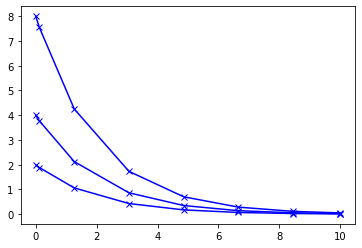

In [36]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
%matplotlib inline

## Simple example of solve_ivp()

def exponential_decay(t, y):
    out = -0.5*y
    return(out)

sol = solve_ivp(exponential_decay, [0, 10], [2, 4, 8, 10, 12], dense_output = True)
plt.plot(sol.t, sol.y[0], 'bx-')
plt.plot(sol.t, sol.y[1], 'bx-')
plt.plot(sol.t, sol.y[2], 'bx-')
plt.show()

In [37]:
# Demonstration of termination event: Cannon fired, termination upon impact

def upward_cannon(t, y):
    return([y[1], -0.5])

def hit_ground(t, y):
    return(y[0])

hit_ground.terminal = True
hit_ground.direction = -1

sol = solve_ivp(upward_cannon, [0, 100], [0, 10])

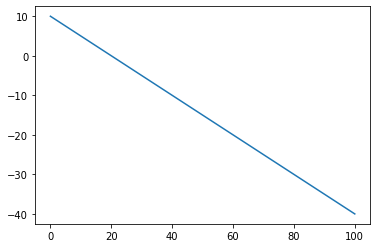

In [38]:
plt.plot(sol.t, sol.y[1])

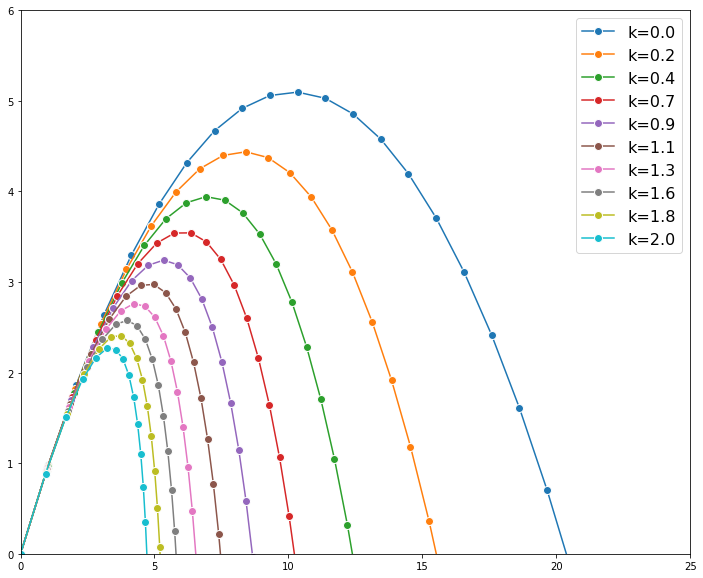

In [43]:
import numpy as np
import scipy.integrate as spi
import matplotlib.pyplot as plt
%matplotlib inline

m = 1. # particle mass
k = 1. # drag coefficient
g = 9.81 # gravity acceleration


v0 = np.zeros(4)# initial position
v0[2] = 10.
v0[3] = 10.

def f(v, t0, k):
    
    u, udot = v[:2], v[2:]
    
    udotdot = -k / m * udot
    udotdot[1] -= g
    
    return(np.r_[udot, udotdot])

fig, ax = plt.subplots(1, 1, figsize = (12, 10))
t = np.linspace(0.0, 3.0, 30)


for k in np.linspace(0.0, 2.0, 10):
    v = spi.odeint(f, v0, t, args = (k,))
    ax.plot(v[:, 0], v[:, 1], 'o-', mew = 1, ms = 8, mec = 'w', label = f'k={k:.1f}')
    
ax.legend()
ax.set_xlim(0, 25)
ax.set_ylim(0, 6)
plt.show()